In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [2]:
transaction_df = pd.read_csv(r"C:\Users\ktkri\Downloads\train_transaction.csv\train_transaction.csv")
identity_df = pd.read_csv(r"C:\Users\ktkri\Downloads\train_identity.csv\train_identity.csv") 

In [3]:
print("Transaction Dataset Shape:", transaction_df.shape)
print("Identity Dataset Shape:", identity_df.shape)  

Transaction Dataset Shape: (590540, 394)
Identity Dataset Shape: (144233, 41)


In [4]:
merged_df = pd.merge(
    transaction_df,
    identity_df,
    on="TransactionID",
    how="left"
)  

In [5]:
print("Merged Dataset Shape:", merged_df.shape)  

Merged Dataset Shape: (590540, 434)


In [6]:
merged_df.dtypes  

TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
                   ...   
id_36              object
id_37              object
id_38              object
DeviceType         object
DeviceInfo         object
Length: 434, dtype: object

In [7]:
merged_df.head(10)  

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
merged_df["isFraud"].value_counts()  

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [9]:
fraud_percentage = (
    merged_df["isFraud"].value_counts(normalize=True) * 100
)

print(fraud_percentage)  

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


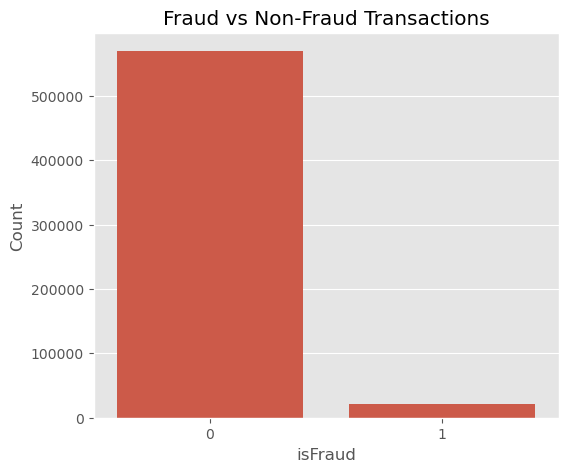

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(x=merged_df["isFraud"])

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("isFraud")
plt.ylabel("Count")

plt.show() 

### Observation

The dataset is highly imbalanced because fraudulent transactions are very small compared to legitimate transactions.

This imbalance can affect machine learning performance and requires special handling later.

In [11]:
missing_values = merged_df.isnull().sum()

missing_values = missing_values[
    missing_values > 0
]

missing_df = pd.DataFrame({
    
    "Missing_Count": missing_values,
    
    "Missing_Percentage": (
        missing_values / len(merged_df)
    ) * 100
})

missing_df.sort_values(
    by="Missing_Percentage",
    ascending=False
).head(20) 

,Missing_Count,Missing_Percentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_23,585371,99.124699
id_22,585371,99.124699
id_27,585371,99.124699
dist2,552913,93.628374


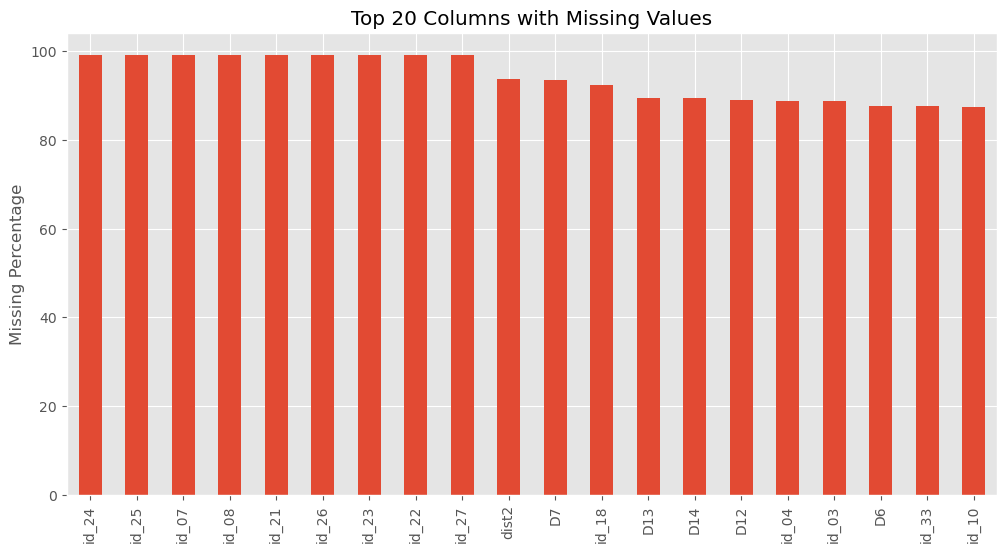

In [12]:
plt.figure(figsize=(12,6))

missing_df["Missing_Percentage"] \
    .sort_values(ascending=False) \
    .head(20) \
    .plot(kind="bar")

plt.title("Top 20 Columns with Missing Values")

plt.ylabel("Missing Percentage")

plt.show() 

### Missing Value Strategy

Columns having more than 50% missing values will be dropped in preprocessing.

Remaining missing values will be imputed using:
- Median for numerical columns
- Mode for categorical columns 

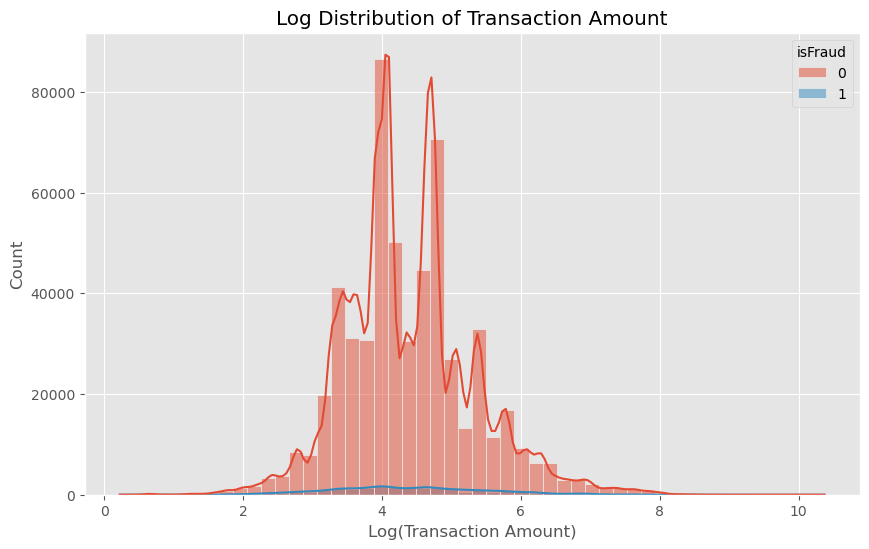

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=merged_df,
    x=np.log1p(merged_df["TransactionAmt"]),
    hue="isFraud",
    bins=50,
    kde=True
)

plt.title("Log Distribution of Transaction Amount")

plt.xlabel("Log(Transaction Amount)")

plt.show() 

Task 2 — Preprocessing, Imbalance Handling & Feature Engineering

In [14]:
missing_percentage = (
    merged_df.isnull().mean() * 100
)

cols_to_drop = missing_percentage[
    missing_percentage > 50
].index

clean_df = merged_df.drop(
    columns=cols_to_drop
)

print(clean_df.shape) 

(590540, 220)


In [15]:
numerical_cols = clean_df.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = clean_df.select_dtypes(
    include=["object"]
).columns 

In [16]:
for col in numerical_cols:
    
    clean_df[col].fillna(
        clean_df[col].median(),
        inplace=True
    ) 

In [17]:
for col in categorical_cols:
    
    clean_df[col].fillna(
        clean_df[col].mode()[0],
        inplace=True
    ) 

In [18]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_cols:
    
    le = LabelEncoder()
    
    clean_df[col] = le.fit_transform(
        clean_df[col].astype(str)
    )
    
    label_encoders[col] = le 

In [19]:
clean_df["AmtToMeanRatio"] = (
    clean_df["TransactionAmt"] /
    clean_df["TransactionAmt"].mean()
) 

In [20]:
clean_df["HourOfDay"] = (
    clean_df["TransactionDT"] // 3600
) % 24 

In [21]:
clean_df["LogTransactionAmt"] = np.log1p(
    clean_df["TransactionAmt"]
) 

In [22]:
X = clean_df.drop(
    columns=["isFraud"]
)

y = clean_df["isFraud"] 

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size=0.2,
    
    stratify=y,
    
    random_state=42
) 

In [24]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
) 

In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    
    X_train_scaled,
    y_train
) 

In [27]:
print("Before SMOTE")

print(y_train.value_counts())

print("\nAfter SMOTE")

print(y_train_smote.value_counts())

Before SMOTE
isFraud
0    455902
1     16530
Name: count, dtype: int64

After SMOTE
isFraud
0    455902
1    455902
Name: count, dtype: int64


# Task 2 Summary

- Removed high-missing-value columns
- Imputed missing values
- Encoded categorical variables
- Created engineered fraud features
- Applied RobustScaler
- Balanced dataset using SMOTE 

Task 3 — Model Training & Evaluation

In [29]:
!pip install lightgbm xgboost

In [30]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
) 

In [31]:
lgbm_model = LGBMClassifier(
    
    n_estimators=200,
    
    learning_rate=0.05,
    
    max_depth=8,
    
    random_state=42
)

lgbm_model.fit(
    X_train_smote,
    y_train_smote
) 

[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.649930 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 53348
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(learning_rate=0.05, max_depth=8, n_estimators=200,
               random_state=42)

In [32]:
xgb_model = XGBClassifier(
    
    n_estimators=200,
    
    learning_rate=0.05,
    
    max_depth=8,
    
    random_state=42,
    
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
) 

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [33]:
iso_model = IsolationForest(
    
    contamination=0.035,
    
    random_state=42
)

iso_model.fit(X_train_scaled) 

IsolationForest(contamination=0.035, random_state=42)

In [34]:
lgbm_preds = lgbm_model.predict(
    X_test_scaled
)

lgbm_probs = lgbm_model.predict_proba(
    X_test_scaled
)[:,1]

In [35]:
xgb_preds = xgb_model.predict(
    X_test_scaled
)

xgb_probs = xgb_model.predict_proba(
    X_test_scaled
)[:,1] 

In [36]:
iso_preds = iso_model.predict(
    X_test_scaled
)

iso_preds = np.where(
    iso_preds == -1,
    1,
    0
) 

In [37]:
def evaluate_model(
    y_true,
    y_pred,
    y_prob=None
):
    
    print(
        "Accuracy:",
        accuracy_score(y_true, y_pred)
    )
    
    print(
        "Precision:",
        precision_score(y_true, y_pred)
    )
    
    print(
        "Recall:",
        recall_score(y_true, y_pred)
    )
    
    print(
        "F1 Score:",
        f1_score(y_true, y_pred)
    )
    
    if y_prob is not None:
        
        print(
            "ROC-AUC:",
            roc_auc_score(
                y_true,
                y_prob
            )
        )
        
        print(
            "PR-AUC:",
            average_precision_score(
                y_true,
                y_prob
            )
        ) 

In [38]:
print("LightGBM Results")

evaluate_model(
    y_test,
    lgbm_preds,
    lgbm_probs
) 

LightGBM Results
Accuracy: 0.9724574118603312
Precision: 0.6577060931899642
Recall: 0.44398741834018873
F1 Score: 0.5301170013000145
ROC-AUC: 0.8875606059054109
PR-AUC: 0.5280501143620113


In [39]:
print("XGBoost Results")

evaluate_model(
    y_test,
    xgb_preds,
    xgb_probs
) 

XGBoost Results
Accuracy: 0.97504826091374
Precision: 0.7057598889659958
Recall: 0.4921364626179531
F1 Score: 0.5799002138275124
ROC-AUC: 0.9128980545788696
PR-AUC: 0.5993673745940724


In [40]:
print("Isolation Forest Results")

evaluate_model(
    y_test,
    iso_preds
) 

Isolation Forest Results
Accuracy: 0.9413248890845667
Precision: 0.1693071648143769
Recall: 0.17323977740140334
F1 Score: 0.17125089691461373


In [42]:
def plot_confusion_matrix(
    y_true,
    y_pred,
    title
):
    
    cm = confusion_matrix(
        y_true,
        y_pred
    )
    
    plt.figure(figsize=(5,4))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    
    plt.title(title)
    
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.show() 

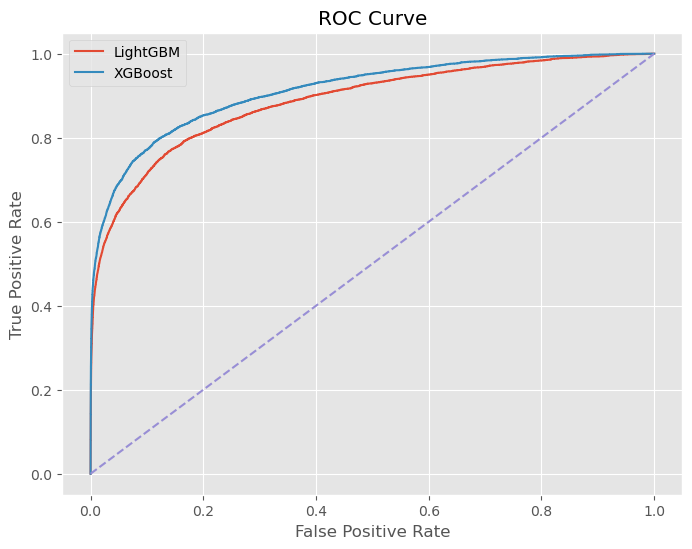

In [43]:
lgbm_fpr, lgbm_tpr, _ = roc_curve(
    y_test,
    lgbm_probs
)

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_test,
    xgb_probs
)

plt.figure(figsize=(8,6))

plt.plot(
    lgbm_fpr,
    lgbm_tpr,
    label="LightGBM"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label="XGBoost"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show() 

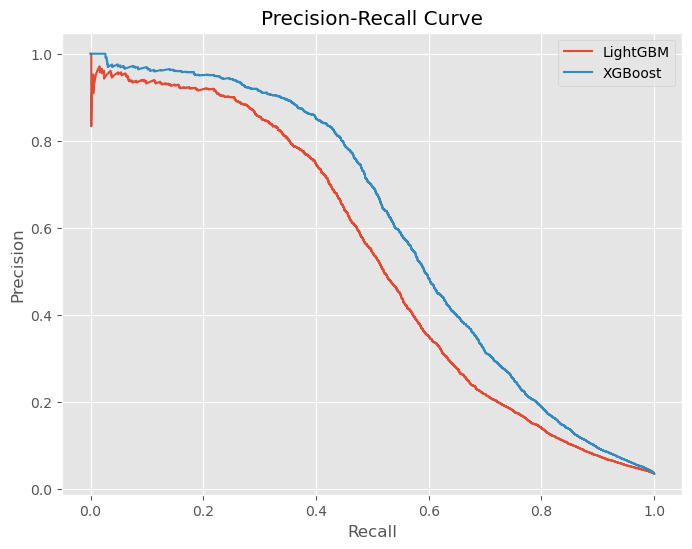

In [44]:
lgbm_precision, lgbm_recall, _ = precision_recall_curve(
    y_test,
    lgbm_probs
)

xgb_precision, xgb_recall, _ = precision_recall_curve(
    y_test,
    xgb_probs
)

plt.figure(figsize=(8,6))

plt.plot(
    lgbm_recall,
    lgbm_precision,
    label="LightGBM"
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label="XGBoost"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show() 

In [45]:
thresholds = np.arange(
    0.1,
    1.0,
    0.05
)

f1_scores = []

for threshold in thresholds:
    
    preds = (
        lgbm_probs >= threshold
    ).astype(int)
    
    score = f1_score(
        y_test,
        preds
    )
    
    f1_scores.append(score) 

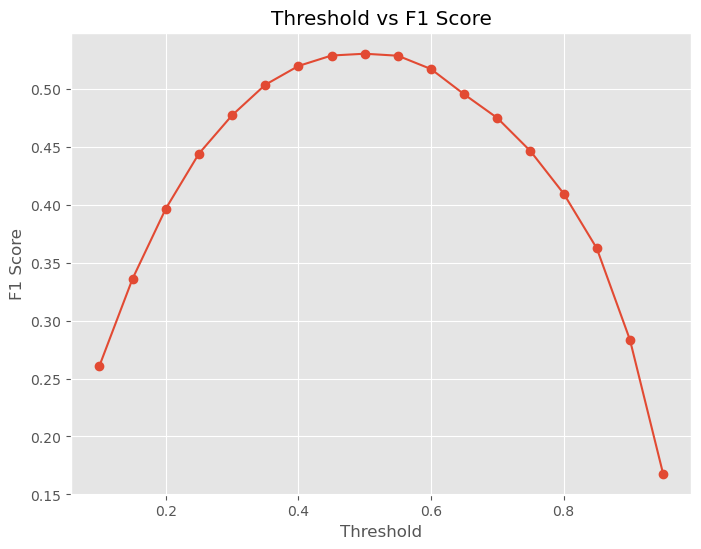

In [46]:
plt.figure(figsize=(8,6))

plt.plot(
    thresholds,
    f1_scores,
    marker="o"
)

plt.xlabel("Threshold")

plt.ylabel("F1 Score")

plt.title("Threshold vs F1 Score")

plt.show() 

In [47]:
best_threshold = thresholds[
    np.argmax(f1_scores)
]

print(best_threshold) 

0.5000000000000001


In [48]:
optimized_preds = (
    lgbm_probs >= best_threshold
).astype(int) 

In [49]:
evaluate_model(
    y_test,
    optimized_preds,
    lgbm_probs
) 

Accuracy: 0.9724574118603312
Precision: 0.6577060931899642
Recall: 0.44398741834018873
F1 Score: 0.5301170013000145
ROC-AUC: 0.8875606059054109
PR-AUC: 0.5280501143620113


In [50]:
feature_importance = pd.DataFrame({
    
    "Feature": X.columns,
    
    "Importance": lgbm_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    
    by="Importance",
    
    ascending=False
) 

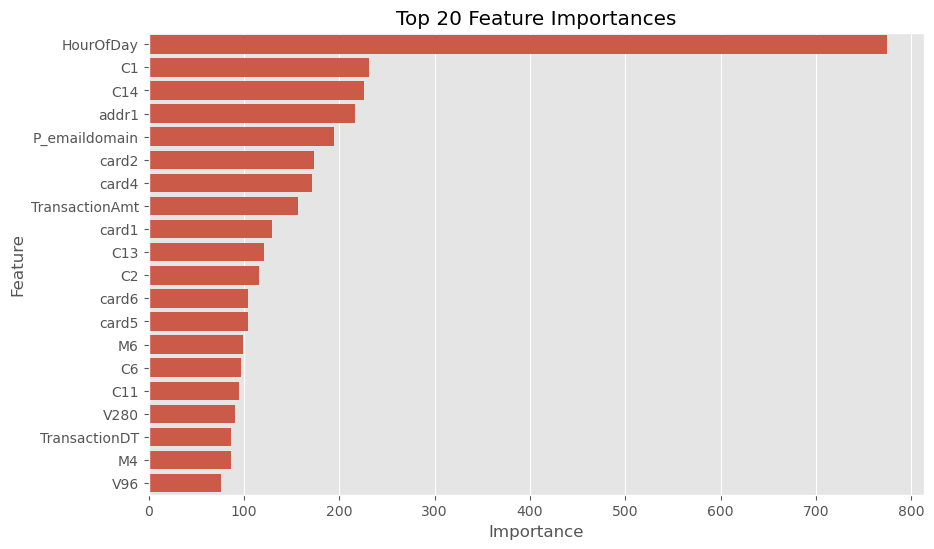

In [51]:
plt.figure(figsize=(10,6))

sns.barplot(
    
    data=feature_importance.head(20),
    
    x="Importance",
    
    y="Feature"
)

plt.title(
    "Top 20 Feature Importances"
)

plt.show() 

In [53]:
import os
import joblib

os.makedirs(
    "models",
    exist_ok=True
)

joblib.dump(
    lgbm_model,
    "models/lightgbm_model.pkl"
)

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

joblib.dump(
    label_encoders,
    "models/label_encoders.pkl"
) 

['models/label_encoders.pkl']

# Task 3 Summary

- Trained LightGBM, XGBoost, and Isolation Forest models
- Evaluated models using multiple metrics
- Visualized ROC and PR curves
- Optimized threshold using F1-score
- Analysed feature importance
- Saved trained model for deployment

In [54]:
!pip install shap 

In [56]:
import shap 

In [57]:
explainer = shap.TreeExplainer(
    lgbm_model
) 

In [58]:
sample_data = X_test_scaled[:1000] 

In [59]:
shap_values = explainer.shap_values(
    sample_data
) 

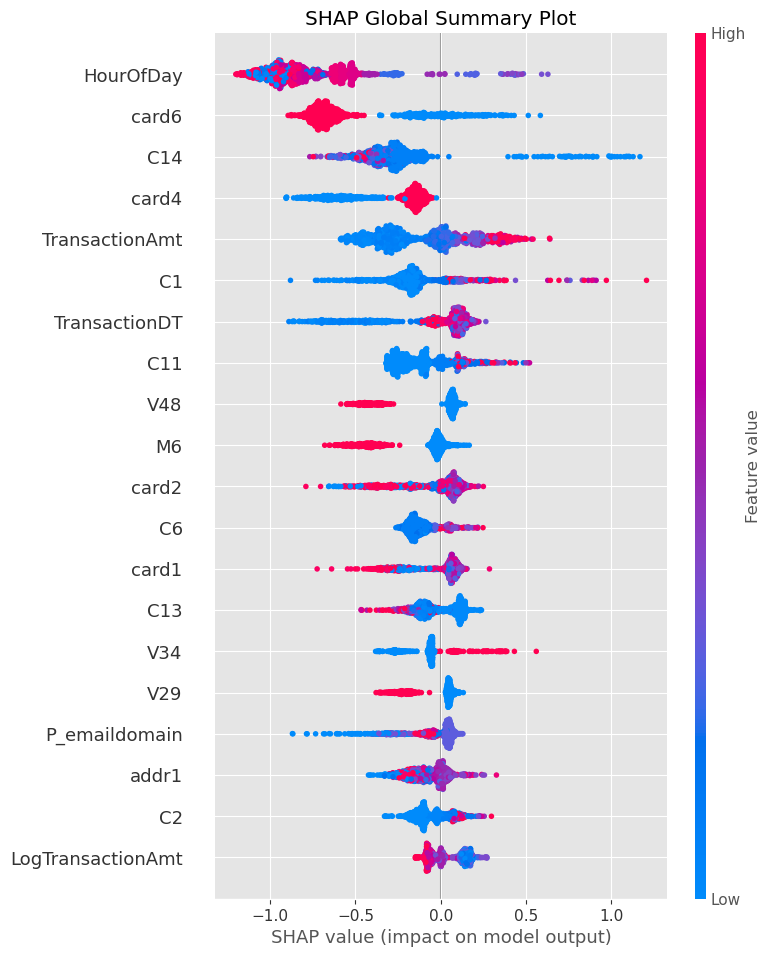

In [60]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    
    shap_values,
    
    sample_data,
    
    feature_names=X.columns,
    
    show=False
)

plt.title(
    "SHAP Global Summary Plot"
)

plt.show() 

In [62]:
import os

os.makedirs(
    "charts",
    exist_ok=True
) 

In [63]:
plt.savefig(
    "charts/shap_summary.png",
    bbox_inches="tight"
) 

<Figure size 640x480 with 0 Axes>

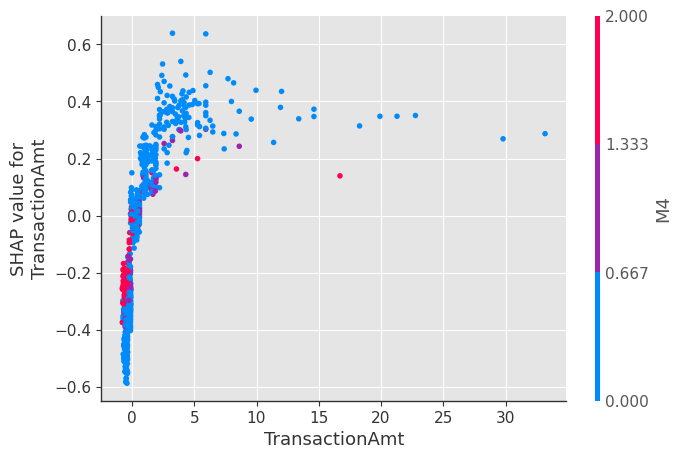

In [64]:
shap.dependence_plot(
    
    "TransactionAmt",
    
    shap_values,
    
    sample_data,
    
    feature_names=X.columns
) 

In [65]:
sample_probs = lgbm_model.predict_proba(
    sample_data
)[:,1] 

In [66]:
fraud_index = np.argmax(
    sample_probs
) 

In [67]:
borderline_index = np.argmin(
    np.abs(sample_probs - 0.50)
) 

In [68]:
legit_index = np.argmin(
    sample_probs
) 

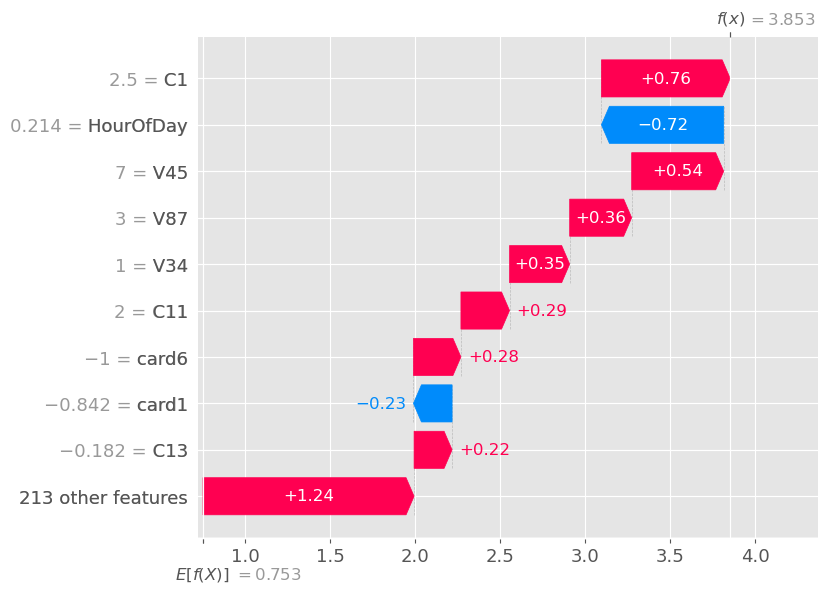

In [69]:
shap.plots.waterfall(
    
    shap.Explanation(
        
        values=shap_values[fraud_index],
        
        base_values=explainer.expected_value,
        
        data=sample_data[fraud_index],
        
        feature_names=X.columns.tolist()
    )
) 

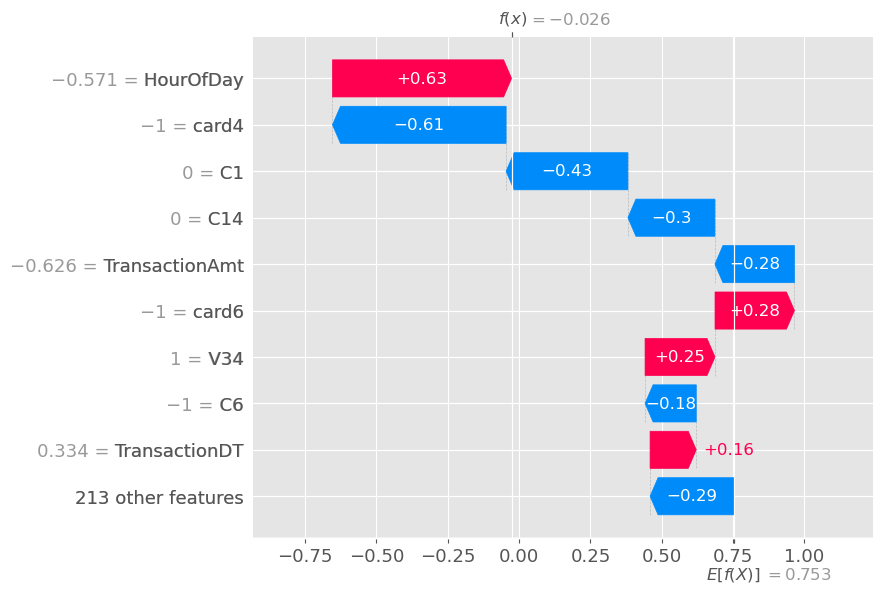

In [70]:
shap.plots.waterfall(
    
    shap.Explanation(
        
        values=shap_values[borderline_index],
        
        base_values=explainer.expected_value,
        
        data=sample_data[borderline_index],
        
        feature_names=X.columns.tolist()
    )
) 

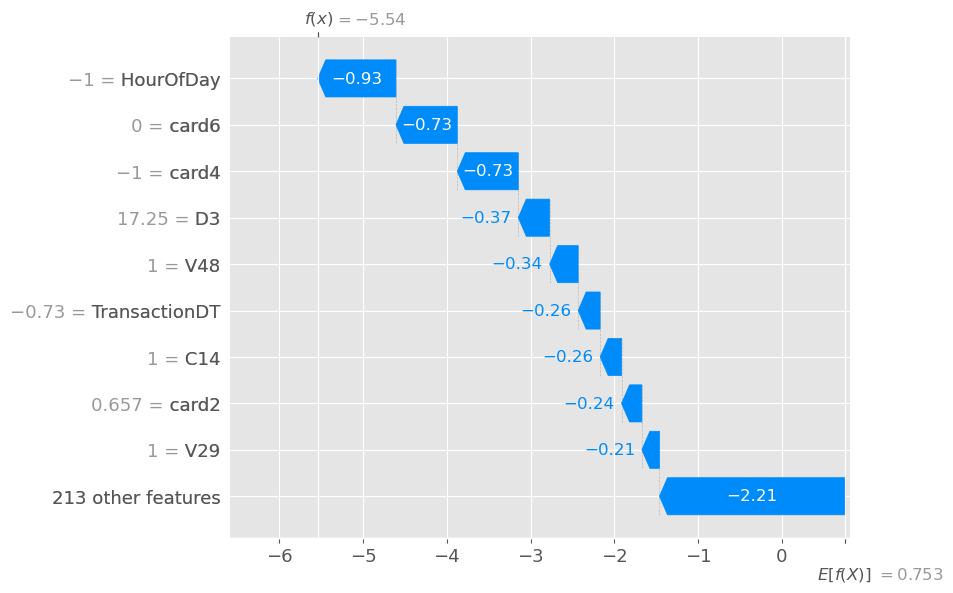

In [71]:
shap.plots.waterfall(
    
    shap.Explanation(
        
        values=shap_values[legit_index],
        
        base_values=explainer.expected_value,
        
        data=sample_data[legit_index],
        
        feature_names=X.columns.tolist()
    )
) 

In [72]:
shap_importance = pd.DataFrame({
    
    "Feature": X.columns,
    
    "SHAP Importance": np.abs(
        shap_values
    ).mean(axis=0)
}) 

In [73]:
shap_importance = shap_importance.sort_values(
    
    by="SHAP Importance",
    
    ascending=False
) 

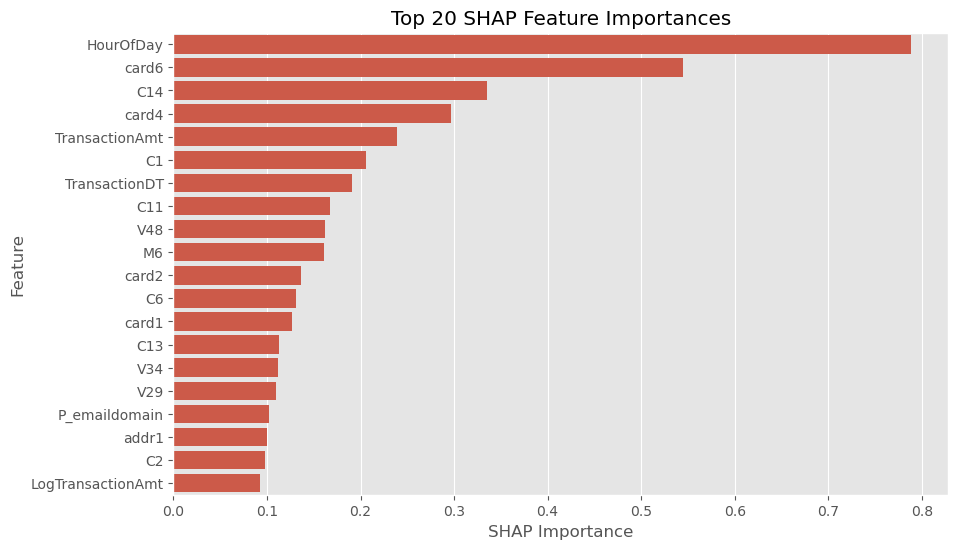

In [74]:
plt.figure(figsize=(10,6))

sns.barplot(
    
    data=shap_importance.head(20),
    
    x="SHAP Importance",
    
    y="Feature"
)

plt.title(
    "Top 20 SHAP Feature Importances"
)

plt.show() 

# Task 4 Summary

- Implemented Explainable AI using SHAP
- Generated global feature importance visualization
- Created transaction-level waterfall explanations
- Compared SHAP feature impact
- Explained fraud predictions in interpretable form 

In [75]:
folders = [
    "charts",
    "models",
    "dashboard",
    "data"
]

for folder in folders:
    
    os.makedirs(
        folder,
        exist_ok=True
    ) 

Task 5 — Risk Segmentation & Fraud Pattern Analysis

In [76]:
fraud_probabilities = lgbm_model.predict_proba(
    X_test_scaled
)[:,1] 

In [77]:
risk_df = X_test.copy()

risk_df["FraudProbability"] = fraud_probabilities

risk_df["ActualFraud"] = y_test.values 

In [78]:
def assign_risk_tier(prob):
    
    if prob >= 0.75:
        return "Critical Risk"
    
    elif prob >= 0.40:
        return "Suspicious"
    
    else:
        return "Clear" 

In [79]:
risk_df["RiskTier"] = risk_df[
    "FraudProbability"
].apply(assign_risk_tier) 

In [80]:
risk_counts = risk_df[
    "RiskTier"
].value_counts()

print(risk_counts) 

RiskTier
Clear            114253
Suspicious         2393
Critical Risk      1462
Name: count, dtype: int64


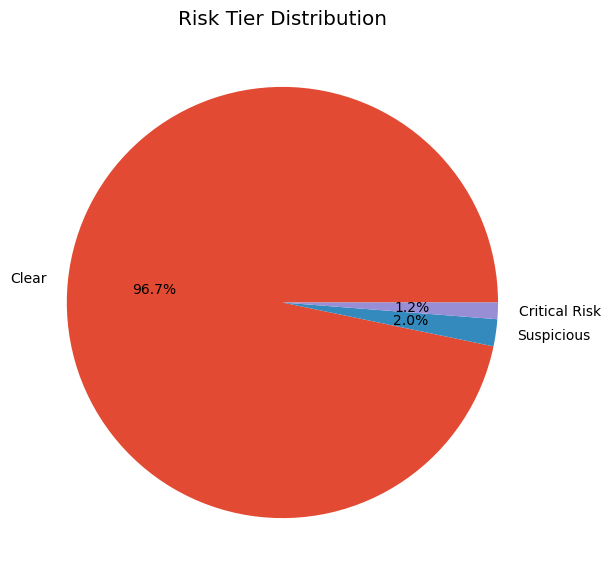

In [81]:
plt.figure(figsize=(7,7))

risk_counts.plot(
    
    kind="pie",
    
    autopct="%1.1f%%"
)

plt.title(
    "Risk Tier Distribution"
)

plt.ylabel("")

plt.show() 

In [82]:
plt.savefig(
    "charts/risk_tier_donut.png",
    bbox_inches="tight"
) 

<Figure size 640x480 with 0 Axes>

In [83]:
avg_amount = risk_df.groupby(
    
    "RiskTier"
)["TransactionAmt"].mean()

print(avg_amount) 

RiskTier
Clear            135.168012
Critical Risk     92.042482
Suspicious       145.763528
Name: TransactionAmt, dtype: float64


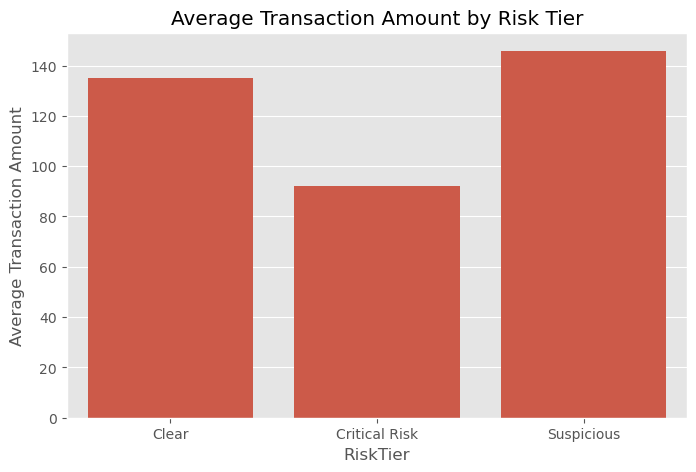

In [84]:
plt.figure(figsize=(8,5))

sns.barplot(
    
    x=avg_amount.index,
    
    y=avg_amount.values
)

plt.title(
    "Average Transaction Amount by Risk Tier"
)

plt.ylabel(
    "Average Transaction Amount"
)

plt.show() 

In [85]:
if "DeviceType" in risk_df.columns:
    
    device_distribution = pd.crosstab(
        
        risk_df["RiskTier"],
        
        risk_df["DeviceType"]
    )
    
    print(device_distribution) 

In [86]:
if "DeviceType" in risk_df.columns:
    
    device_distribution.plot(
        
        kind="bar",
        
        figsize=(10,6)
    )
    
    plt.title(
        "Device Type Distribution Across Risk Tiers"
    )
    
    plt.ylabel(
        "Transaction Count"
    )
    
    plt.show() 

In [87]:
hour_pattern = risk_df.groupby(
    
    "HourOfDay"
)["FraudProbability"].mean() 

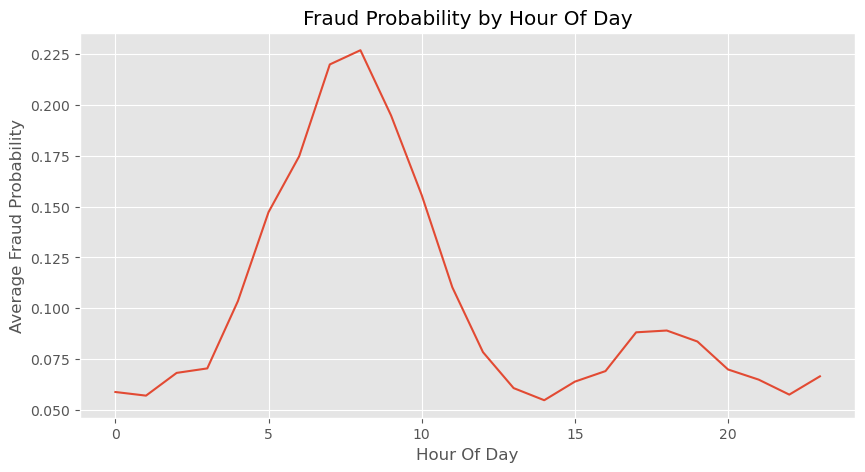

In [88]:
plt.figure(figsize=(10,5))

sns.lineplot(
    
    x=hour_pattern.index,
    
    y=hour_pattern.values
)

plt.title(
    "Fraud Probability by Hour Of Day"
)

plt.xlabel(
    "Hour Of Day"
)

plt.ylabel(
    "Average Fraud Probability"
)

plt.show() 

In [90]:
tier_summary = risk_df.groupby(
    
    "RiskTier"
).agg({
    
    "TransactionAmt": "mean",
    
    "FraudProbability": "mean"
}) 

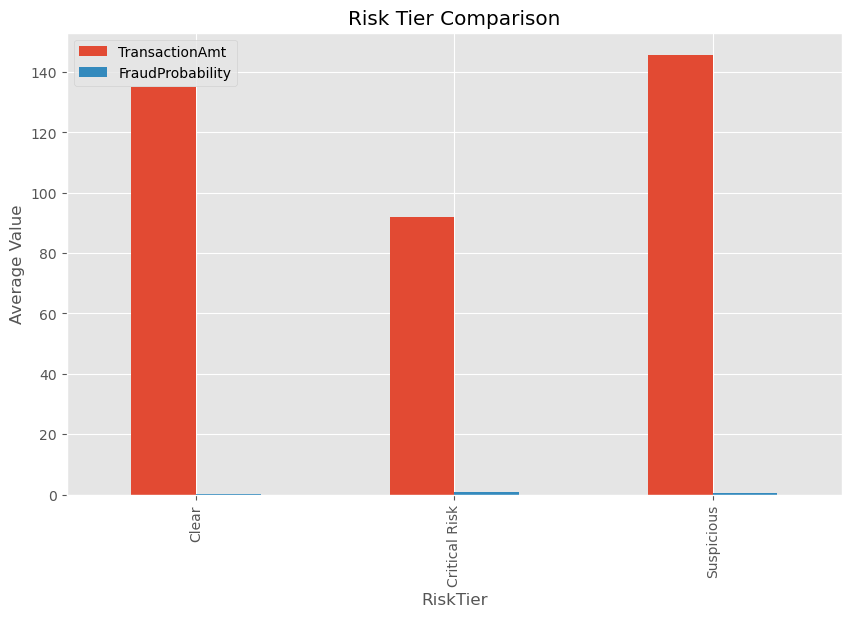

In [91]:
tier_summary.plot(
    
    kind="bar",
    
    figsize=(10,6)
)

plt.title(
    "Risk Tier Comparison"
)

plt.ylabel(
    "Average Value"
)

plt.show() 

In [92]:
critical_risk_df = risk_df[
    
    risk_df["RiskTier"] == "Critical Risk"
] 

In [93]:
print(
    critical_risk_df[
        "TransactionAmt"
    ].mean()
) 

92.04248153214775


In [94]:
print(
    critical_risk_df[
        "HourOfDay"
    ].mode()[0]
) 

18


In [95]:
if "DeviceType" in critical_risk_df.columns:
    
    print(
        critical_risk_df[
            "DeviceType"
        ].mode()[0]
    ) 

In [96]:
import plotly.express as px 

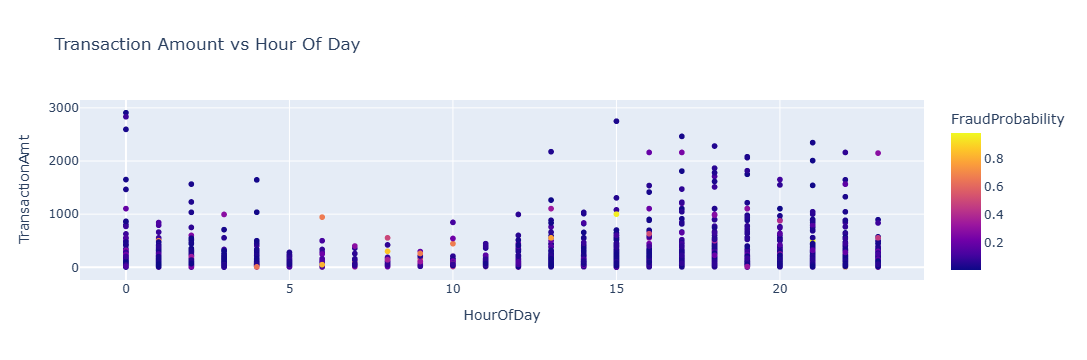

In [98]:
fig = px.scatter(
    
    risk_df.sample(5000),
    
    x="HourOfDay",
    
    y="TransactionAmt",
    
    color="FraudProbability",
    
    title="Transaction Amount vs Hour Of Day"
)

fig.show() 

# Task 5 Summary

- Segmented transactions into risk categories
- Analysed fraud probability patterns
- Investigated transaction timing behavior
- Compared transaction characteristics across risk tiers
- Identified major fraud-related behavioral patterns 